In [1]:
# Module 1: Data Collection
import pandas as pd

df = pd.read_csv("Superstore.csv", encoding='latin1')

# Basic overview
print(df.head())
print(df.info())
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [2]:
# 1. Check missing values
print("Missing values:\n", df.isnull().sum())

# 2. Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# 3. Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 4. Check data types
print("\nData types:\n", df.dtypes)

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Duplicate rows: 0

Data types:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             ob

In [3]:
print("Rows, Columns:", df.shape)
print("\nColumns:\n", df.columns)


Rows, Columns: (9994, 21)

Columns:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity  

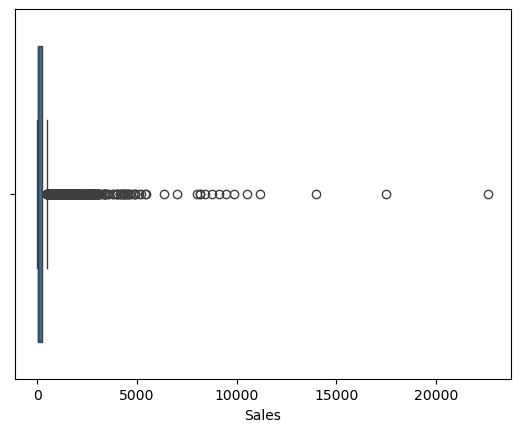

In [4]:
#Module 2 Data Cleaning & Preprocessing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Superstore.csv", encoding='latin1')

print(df.isnull().sum())
print(df.duplicated().sum())

df = df.drop_duplicates()

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.dtypes)

sns.boxplot(x=df['Sales'])
plt.show()

df.to_csv("cleaned_data.csv", index=False)

In [5]:
##Module 3 – Data Analysis

# Category-wise sales
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

# Region-wise profit
region_profit = df.groupby('Region')['Profit'].sum()
print(region_profit)

# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64
Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400

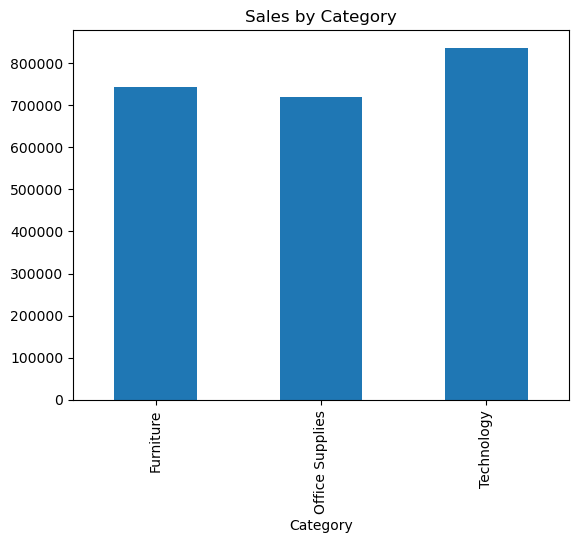

In [7]:
#Module 5 – Insights & Conclusion
#Sales by Category
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

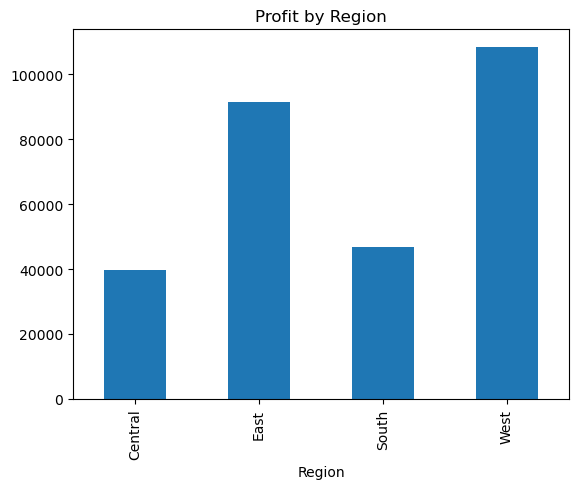

In [8]:
#Profit by Region
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Region")
plt.show()

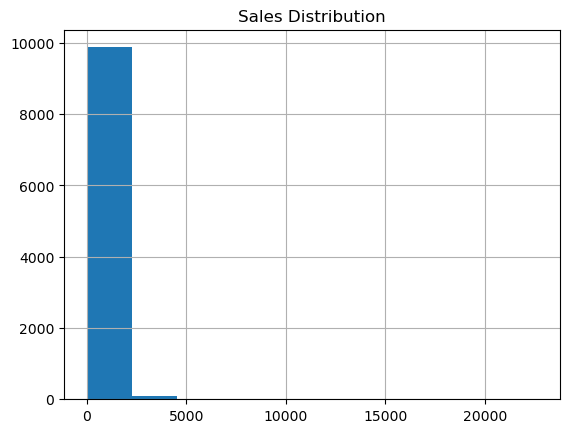

In [9]:
#Sales Distribution
df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()

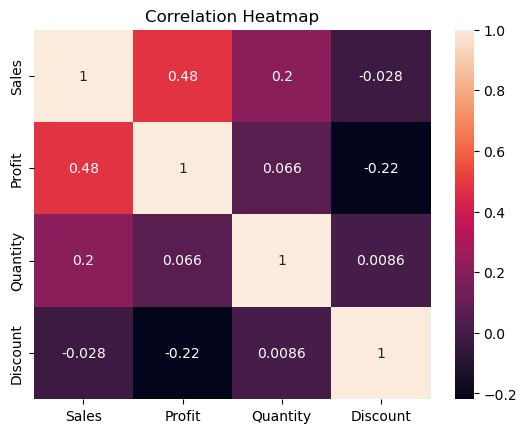

In [10]:
#Correlation Heatmap
sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

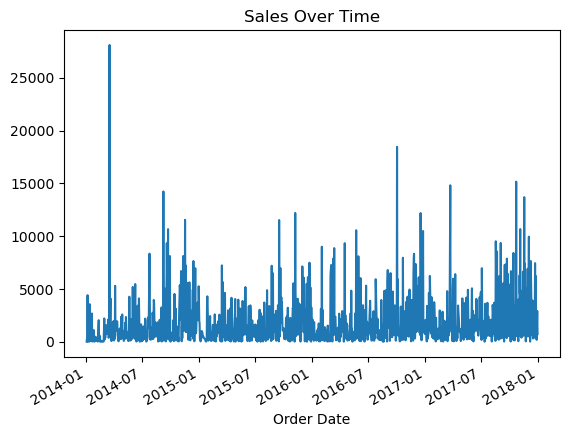

In [11]:
#Sales Over Time
df.groupby('Order Date')['Sales'].sum().plot()
plt.title("Sales Over Time")
plt.show()

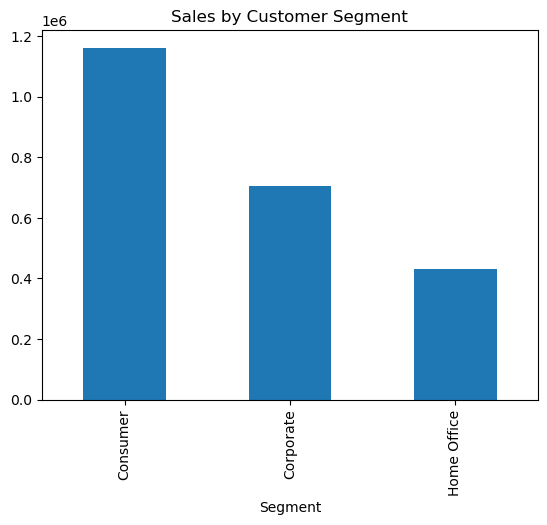

In [12]:
df.groupby('Segment')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.show()